# Práctica 5: Modelos lineales y correlación

Se genera un modelo de regresión lineal simple para predecir `loudness` a partir de `energy`, se grafica y se obtiene la métrica R².

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

PATH_INPUT = "../data/processed/spotify_cleaned.csv"
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

## Carga de datos

Como cada canción se repite por semana, país y artista, se deja una sola fila por canción (`uri`), ya que `energy` y `loudness` no cambian entre repeticiones.

In [2]:
df = pd.read_csv(PATH_INPUT)
canciones = df.drop_duplicates("uri")
print(f"{len(df)} filas -> {len(canciones)} canciones únicas")

66174 filas -> 2445 canciones únicas


## Correlación

En la Práctica 2 y 3 mencione que `energy` y `loudness` son el par con la relación positiva más clara, así que se usaran para el modelo.

In [3]:
r = canciones["energy"].corr(canciones["loudness"])
print(f"Correlación de Pearson energy vs loudness: r = {r:.3f}")

Correlación de Pearson energy vs loudness: r = 0.713


## Modelo lineal

In [4]:
X = canciones[["energy"]]
y = canciones["loudness"]

modelo = LinearRegression()
modelo.fit(X, y)
y_pred = modelo.predict(X)

r2 = r2_score(y, y_pred)
print(f"loudness = {modelo.intercept_:.3f} + {modelo.coef_[0]:.3f} * energy")
print(f"R² = {r2:.3f}")

loudness = -13.445 + 10.559 * energy
R² = 0.508


## Gráficas

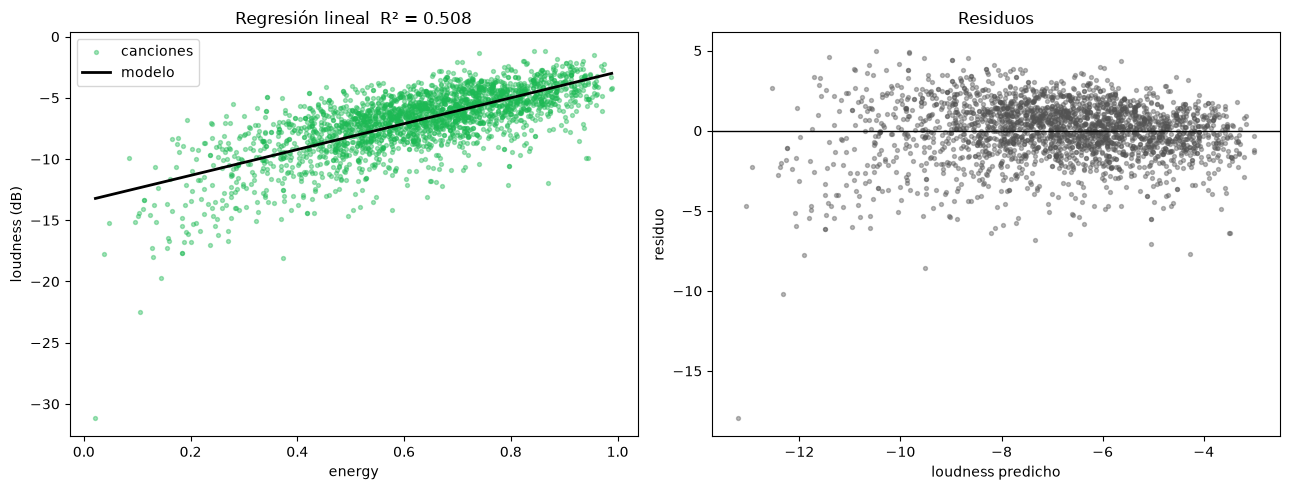

In [5]:
residuos = y - y_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# dispersion con la recta del modelo
axes[0].scatter(X["energy"], y, s=8, alpha=0.4, color="#1DB954", label="canciones")
x_linea = np.linspace(X["energy"].min(), X["energy"].max(), 100)
axes[0].plot(x_linea, modelo.intercept_ + modelo.coef_[0] * x_linea, color="black", lw=2, label="modelo")
axes[0].set_xlabel("energy")
axes[0].set_ylabel("loudness (dB)")
axes[0].set_title(f"Regresión lineal  R² = {r2:.3f}")
axes[0].legend()

# residuos contra valores predichos
axes[1].scatter(y_pred, residuos, s=8, alpha=0.4, color="#535353")
axes[1].axhline(0, color="black", lw=1)
axes[1].set_xlabel("loudness predicho")
axes[1].set_ylabel("residuo")
axes[1].set_title("Residuos")

fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "regresion_energy_loudness.png"), dpi=150)
plt.show()

El modelo obtenido es `loudness = -13.445 + 10.559 * energy`, es decir, por cada 0.1 que sube `energy` el volumen sube cerca de 1 dB.

Con un R² = 0.508 el modelo explica aproximadamente el 51% de la variación de `loudness`, lo cual es coherente con la correlación de r = 0.713 (R² = r² en regresión simple). La otra mitad depende de otros factores como la producción, la mezcla o el género de la canción.

En la gráfica de residuos los puntos están repartidos alrededor de 0 sin un patrón fuerte, aunque en los valores de `energy` más bajos hay más dispersión y algunos valores atípicos (canciones muy suaves con volumen mucho menor al predicho).